In [88]:
import pandas as pd

path = "../../luad_tcga_pan_can_atlas_2018/"

md = pd.read_csv(path + "data_mutations.txt", sep="\t")

/var/folders/z1/6qnpcxk94r50ct3jvdw1nqvm0000gn/T/ipykernel_78814/1995784089.py:5: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  md = pd.read_csv(path + "data_mutations.txt", sep="\t")


In [89]:
md.shape

(243229, 114)

In [90]:
# 1. Keep only PASS calls (removes low-quality variant calls)
md = md[md['FILTER'] == 'PASS']

# 2. Keep mutations called by at least 2 indepexxndent callers
md = md[md['NCALLERS'] >= 2]

print("After quality filter:", md.shape)
print(f"Removed {243229 - len(md):,} low-confidence rows")

After quality filter: (196070, 114)
Removed 47,159 low-confidence rows


In [91]:
#Missingness Analysis
import numpy as np
#Technique: df.replace('.', np.nan).isnull().mean() → sort descending → plot bar chart.
missing = md.replace('.', np.nan).isnull().mean().sort_values(ascending=False)

/var/folders/z1/6qnpcxk94r50ct3jvdw1nqvm0000gn/T/ipykernel_78814/3627761558.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  missing = md.replace('.', np.nan).isnull().mean().sort_values(ascending=False)


In [92]:
missing_nonzero = missing[missing>0]
missing_nonzero

Tumor_Validation_Allele2         1.000000
Score                            1.000000
Match_Norm_Validation_Allele2    1.000000
Verification_Status              1.000000
Validation_Status                1.000000
                                   ...   
HGNC_ID                          0.006702
HGVSc                            0.006610
CANONICAL                        0.002810
Entrez_Gene_Id                   0.000112
Hotspot                          0.000015
Length: 74, dtype: float64

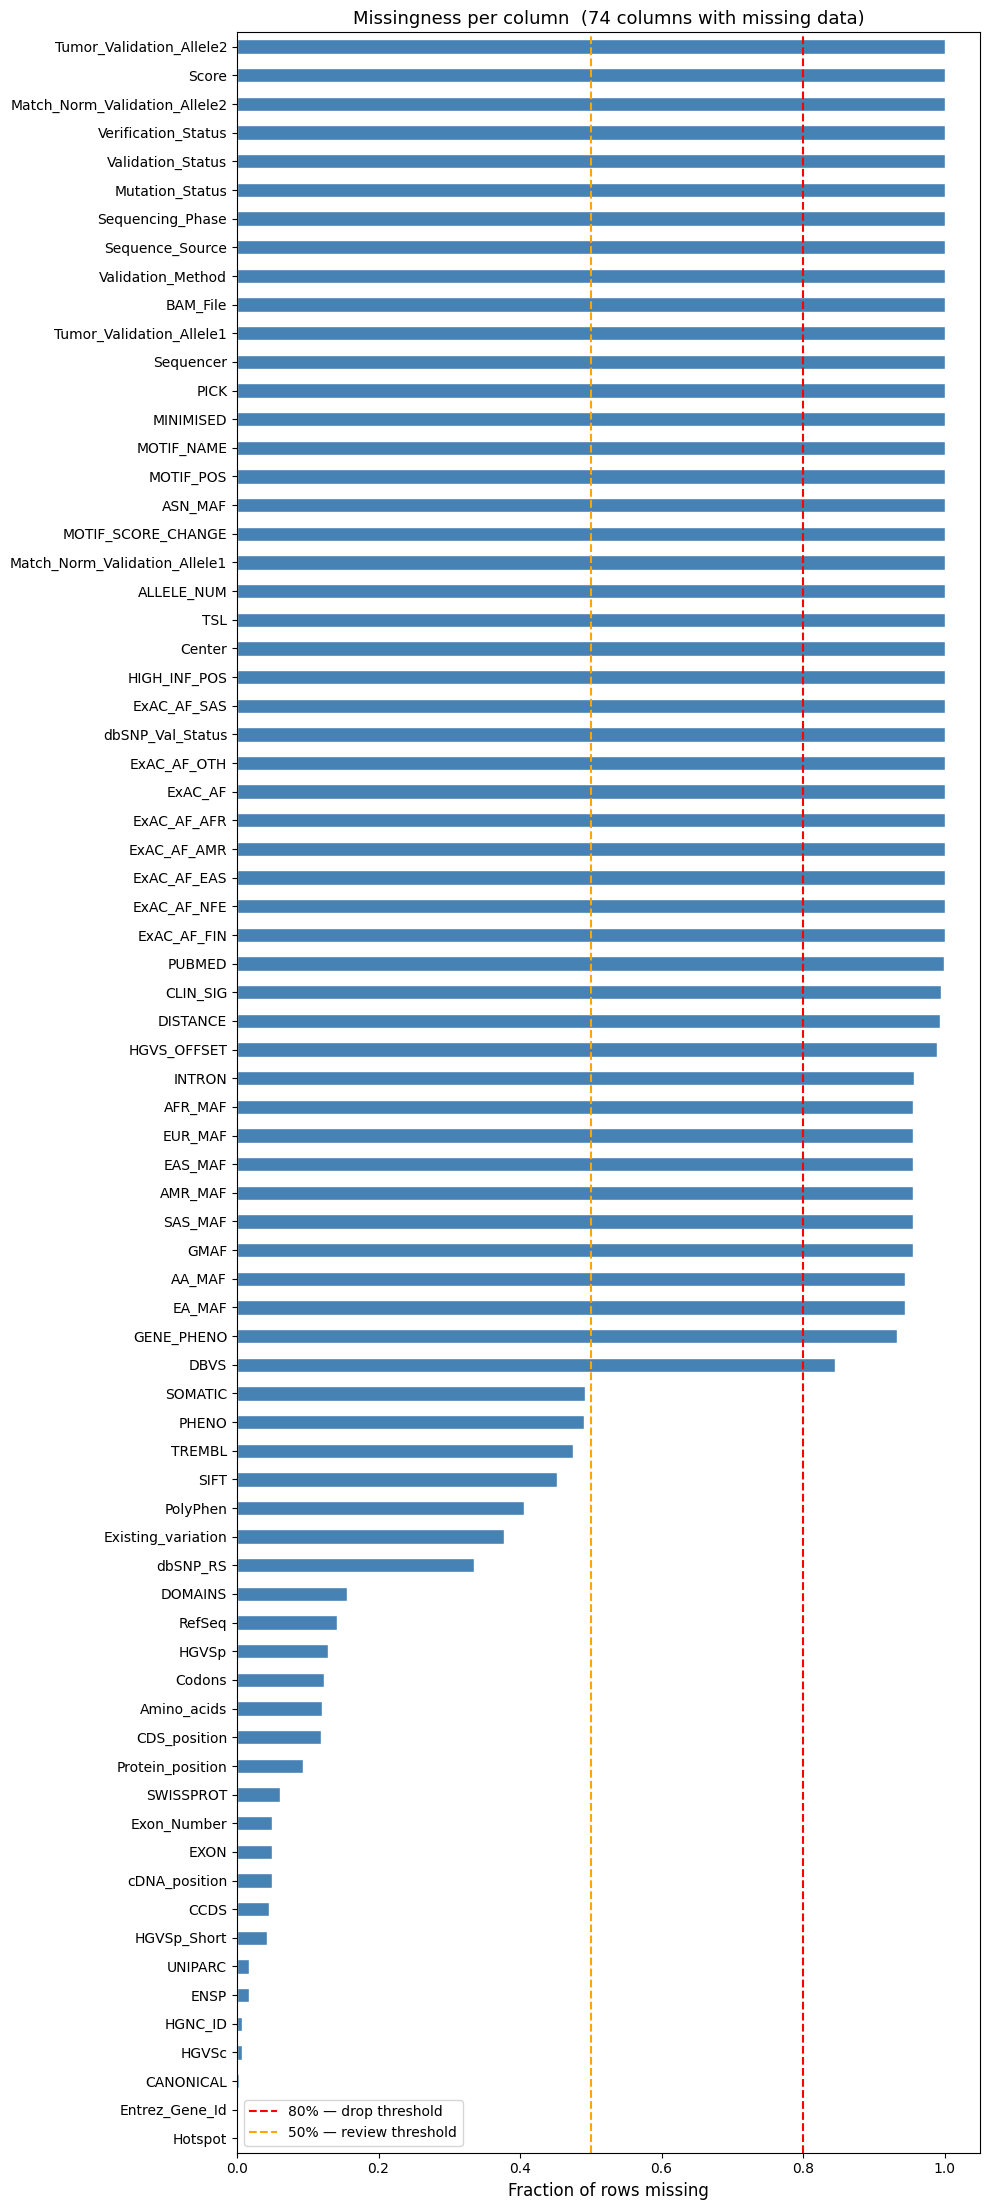


Columns to DROP (>80% missing): 47
['Tumor_Validation_Allele2', 'Score', 'Match_Norm_Validation_Allele2', 'Verification_Status', 'Validation_Status', 'Mutation_Status', 'Sequencing_Phase', 'Sequence_Source', 'Validation_Method', 'BAM_File', 'Tumor_Validation_Allele1', 'Sequencer', 'PICK', 'MINIMISED', 'MOTIF_NAME', 'MOTIF_POS', 'ASN_MAF', 'MOTIF_SCORE_CHANGE', 'Match_Norm_Validation_Allele1', 'ALLELE_NUM', 'TSL', 'Center', 'HIGH_INF_POS', 'ExAC_AF_SAS', 'dbSNP_Val_Status', 'ExAC_AF_OTH', 'ExAC_AF', 'ExAC_AF_AFR', 'ExAC_AF_AMR', 'ExAC_AF_EAS', 'ExAC_AF_NFE', 'ExAC_AF_FIN', 'PUBMED', 'CLIN_SIG', 'DISTANCE', 'HGVS_OFFSET', 'INTRON', 'AFR_MAF', 'EUR_MAF', 'EAS_MAF', 'AMR_MAF', 'SAS_MAF', 'GMAF', 'AA_MAF', 'EA_MAF', 'GENE_PHENO', 'DBVS']


In [93]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, max(6, len(missing_nonzero) * 0.3)))

missing_nonzero.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

# Threshold reference lines
ax.axvline(x=0.8, color='red',    linestyle='--', linewidth=1.5, label='80% — drop threshold')
ax.axvline(x=0.5, color='orange', linestyle='--', linewidth=1.5, label='50% — review threshold')

ax.set_xlabel('Fraction of rows missing', fontsize=12)
ax.set_title(f'Missingness per column  ({len(missing_nonzero)} columns with missing data)', fontsize=13)
ax.legend(fontsize=10)
ax.invert_yaxis()   # highest missingness at the top
plt.tight_layout()
plt.show()

# Summary: which columns cross the 80% drop threshold
drop_cols = missing[missing > 0.8].index.tolist()
print(f"\nColumns to DROP (>80% missing): {len(drop_cols)}")
print(drop_cols)

In [94]:
#Drop columns whihc have 80% of the data as null
md = md.drop(drop_cols, axis=1)

In [95]:
md.shape

(196070, 67)

In [96]:
#Variance and Cardinality Analysis

#remove columns with nunique to be 1.
const_columns = [cols for cols in md.columns if md[cols].nunique()==1]
const_columns

['NCBI_Build', 'Hotspot', 'FILTER', 'Feature_type', 'MERGESOURCE']

In [97]:
#remove the const_columns

md = md.drop(const_columns, axis=1)

In [98]:
# check cardinality of the columns, having unique values more than 10,000 more than 15000, 20000

high_cardinality10k = [cols for cols in md.columns if md[cols].nunique()>=10000]
high_cardinality15k = [cols for cols in md.columns if md[cols].nunique()>=15000]
high_cardinality20k = [cols for cols in md.columns if md[cols].nunique()>=20000]

print(len(high_cardinality10k))
print(len(high_cardinality15k))
print(len(high_cardinality20k))

24
22
10


In [99]:
print(high_cardinality10k)
print(high_cardinality15k)
print(high_cardinality20k)

['Hugo_Symbol', 'Entrez_Gene_Id', 'Start_Position', 'End_Position', 'dbSNP_RS', 'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'RefSeq', 'CCDS', 'CDS_position', 'CONTEXT', 'DOMAINS', 'ENSP', 'Existing_variation', 'Feature', 'Gene', 'HGNC_ID', 'SWISSPROT', 'SYMBOL', 'UNIPARC', 'all_effects', 'cDNA_position']
['Hugo_Symbol', 'Entrez_Gene_Id', 'Start_Position', 'End_Position', 'dbSNP_RS', 'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'RefSeq', 'CCDS', 'CONTEXT', 'DOMAINS', 'ENSP', 'Existing_variation', 'Feature', 'Gene', 'HGNC_ID', 'SWISSPROT', 'SYMBOL', 'UNIPARC', 'all_effects']
['Start_Position', 'End_Position', 'dbSNP_RS', 'HGVSc', 'HGVSp', 'HGVSp_Short', 'CONTEXT', 'DOMAINS', 'Existing_variation', 'all_effects']


In [100]:
cols_to_save = ['Tumor_Sample_Barcode', 'Hugo_Symbol', 
                'Variant_Classification', 'NCALLERS', 'FILTER',
                't_alt_count', 't_depth', 'VAF']

In [101]:
#Remove the cols_to_save from the high_cardinality10k
high_cardinality_to_drop = [col for col in high_cardinality10k if col not in cols_to_save]


In [102]:
#remove the columns having more than 10k cardinality, high_cardinality10k
md = md.drop(high_cardinality_to_drop, axis=1)

In [103]:
md.shape

(196070, 39)

How a tumor forms — the biology behind VAF


A tumor starts from one cell that acquires a mutation. That cell divides, and its daughters all carry that same mutation. This is called a clonal mutation — it's in the founding clone, so every cancer cell in the tumor has it.

When you sequence the tumor, you're reading thousands of DNA fragments from that region. Some come from cancer cells, some from normal cells mixed in (blood vessels, immune cells, stroma).

If mutation is in 50% of cancer cells, and tumor is 80% cancer:
  → ~40% of all reads will carry the mutation
  → VAF ≈ 0.40




  What are "reads"?
DNA sequencing does not read your entire DNA in one go. It shreds the DNA into millions of tiny fragments, reads each fragment individually, then stitches them back together computationally.

Each tiny fragment that gets read = one read.


Your DNA at a specific position:
─────────────────────────────────────────────

  Full DNA:  ...AATCG[G]TTCAA...   ← the [G] is the position we care about

  Sequencer shreds it and reads fragments:

  Read 1:        AATCG[G]TT
  Read 2:          TCGG[G]TTC
  Read 3:         ATCG[G]TTC
  Read 4:        AATCG[G]TTC
  Read 5:          TCGG[G]TT

  All 5 reads say [G] at this position → reference allele


Now imagine a mutation changed G → C in some cancer cells:


  Read 1:  AATCG[G]TT   ← from a normal cell, says G
  Read 2:  AATCG[G]TT   ← from a normal cell, says G
  Read 3:  AATCG[C]TT   ← from a cancer cell, says C  (mutation!)
  Read 4:  AATCG[G]TT   ← from a normal cell, says G
  Read 5:  AATCG[C]TT   ← from a cancer cell, says C  (mutation!)
  Read 6:  AATCG[G]TT   ← from a normal cell, says G
  Read 7:  AATCG[C]TT   ← from a cancer cell, says C  (mutation!)
  Read 8:  AATCG[G]TT   ← from a normal cell, says G

How VAF is calculated
From the 8 reads above:

3 reads say C (the mutant allele) → t_alt_count = 3
5 reads say G (the reference) → t_ref_count = 5
Total reads at this position → t_depth = 8

VAF = t_alt_count / t_depth = 3 / 8 = 0.375
That 0.375 means 37.5% of the tumor tissue at this spot carries the mutation.




When you take a tumor biopsy, you don't get 100% cancer cells. The tissue is a mixture:


  Tumor biopsy (100 cells total):

  ████████████████████████████████   60 cancer cells  (carry the mutation)
  ░░░░░░░░░░░░░░░░░░░░             30 normal cells   (no mutation)
  ▒▒▒▒▒▒▒▒▒▒                       10 immune cells   (no mutation)
So even if all cancer cells have the mutation, VAF won't be 1.0 — it'll be ~0.6 because 40% of reads come from non-cancer cells that don't carry it.


VAF = (cancer cells with mutation) × (fraction of tumor that is cancer)
    = 1.0 × 0.60
    = 0.60
This is exactly what t_alt_count and t_depth in your MAF file are recording — the raw read counts that let you compute this fraction.

In [104]:
#Adding VAF column

# VAF = what fraction of tumor reads carry the mutation
# Close to 0.5 = clonal (one copy mutated in diploid)
# Close to 1.0 = LOH or homozygous mutation
# Very low (< 0.05) = subclonal or possible noise

md['VAF'] = md['t_alt_count'] / md['t_depth']

print(md['VAF'].describe())


count    196070.000000
mean          0.248158
std           0.155509
min           0.018229
25%           0.133333
50%           0.211538
75%           0.323077
max           1.000000
Name: VAF, dtype: float64


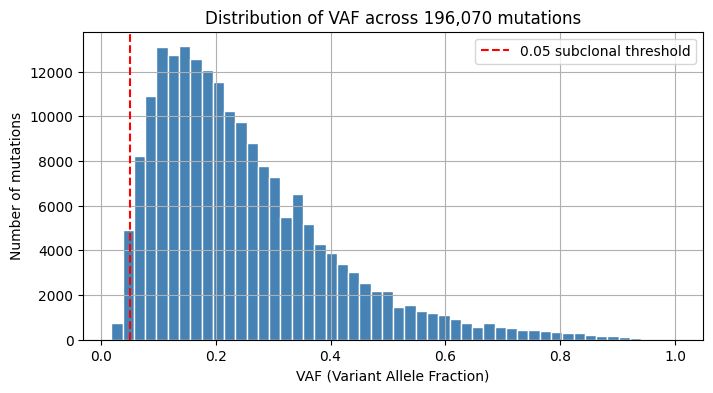

In [105]:
import matplotlib.pyplot as plt

md['VAF'].hist(bins=50, figsize=(8, 4), color='steelblue', edgecolor='white')
plt.xlabel('VAF (Variant Allele Fraction)')
plt.ylabel('Number of mutations')
plt.title('Distribution of VAF across 196,070 mutations')
plt.axvline(x=0.05, color='red', linestyle='--', label='0.05 subclonal threshold')
plt.legend()
plt.show()


In [106]:
md.shape

(196070, 40)

In [107]:
md.columns.to_list()


['Hugo_Symbol',
 'Chromosome',
 'Strand',
 'Consequence',
 'Variant_Classification',
 'Variant_Type',
 'Reference_Allele',
 'Tumor_Seq_Allele1',
 'Tumor_Seq_Allele2',
 'Tumor_Sample_Barcode',
 'Matched_Norm_Sample_Barcode',
 'Match_Norm_Seq_Allele1',
 'Match_Norm_Seq_Allele2',
 't_ref_count',
 't_alt_count',
 'n_ref_count',
 'n_alt_count',
 'Protein_position',
 'Codons',
 'Allele',
 'Amino_acids',
 'BIOTYPE',
 'CANONICAL',
 'CENTERS',
 'COSMIC',
 'EXON',
 'Exon_Number',
 'IMPACT',
 'NCALLERS',
 'PHENO',
 'PolyPhen',
 'SIFT',
 'SOMATIC',
 'SYMBOL_SOURCE',
 'TREMBL',
 'VARIANT_CLASS',
 'n_depth',
 't_depth',
 'Annotation_Status',
 'VAF']

In [108]:
columns_needed = ['Tumor_Sample_Barcode', 'Hugo_Symbol', 'NCALLERS', 'Variant_Classification', 'VAF']
md_raw = md[columns_needed]
# FILTER and NCALLERS already applied upstream — just filter variant type and VAF
nonsynonymous = [
    'Missense_Mutation',
    'Nonsense_Mutation',
    'Frame_Shift_Del',
    'Frame_Shift_Ins',
    'In_Frame_Del',
    'In_Frame_Ins',
    'Splice_Site',
    'Nonstop_Mutation',
    'Translation_Start_Site'
]


md_pivot = md_raw[
    (md_raw['Variant_Classification'].isin(nonsynonymous)) &
    (md_raw['VAF'] >= 0.1)   # removes subclonal/noisy mutations
]

print(md_pivot.shape)
print(md_pivot.head(3))


(116491, 5)
  Tumor_Sample_Barcode Hugo_Symbol  NCALLERS Variant_Classification       VAF
0      TCGA-05-4244-01        CPN1         5      Missense_Mutation  0.209677
2      TCGA-05-4244-01        NEBL         3           In_Frame_Del  0.208696
5      TCGA-05-4244-01       DIP2C         5            Splice_Site  0.213018


In [109]:
# Then TMB (optionally normalize by exome size)
#count the no of mutation for a particular patient
tmb = md_pivot.groupby('Tumor_Sample_Barcode').size().rename('TMB')
#Divide the count by the 38Mb
tmb = tmb / 38  # mutations/Mb — optional but makes it comparable to literature

In [110]:
tmb.head()

Tumor_Sample_Barcode
TCGA-05-4244-01     4.605263
TCGA-05-4249-01     7.052632
TCGA-05-4250-01     7.578947
TCGA-05-4382-01    28.710526
TCGA-05-4384-01     2.578947
Name: TMB, dtype: float64

In [111]:
tmb.index = tmb.index.str[:12]

In [112]:
mutation_matrix = (
    md_pivot.groupby(['Tumor_Sample_Barcode', 'Hugo_Symbol'])
    .size()
    .unstack(fill_value=0)
    .gt(0)
    .astype(int)
)

print(mutation_matrix.shape)

(504, 16410)


In [113]:
mutation_matrix.index = mutation_matrix.index.str[:12]
print(mutation_matrix.index[:5])

Index(['TCGA-05-4244', 'TCGA-05-4249', 'TCGA-05-4250', 'TCGA-05-4382',
       'TCGA-05-4384'],
      dtype='object', name='Tumor_Sample_Barcode')


In [114]:
mutation_matrix['TMB'] = tmb
print("Shape after TMB:", mutation_matrix.shape)  # expect (508, 18779)


Shape after TMB: (504, 16411)


In [115]:
mutation_matrix.head()

Hugo_Symbol,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GNT,AAAS,AACS,AADAC,AADACL2,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,TMB
Tumor_Sample_Barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-05-4244,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4.605263
TCGA-05-4249,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7.052632
TCGA-05-4250,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,7.578947
TCGA-05-4382,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28.710526
TCGA-05-4384,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.578947


In [116]:
# Frequency filter: keep genes mutated in ≥5% of patients
freq = mutation_matrix.drop(columns='TMB').mean()


In [117]:
freq.head()

Hugo_Symbol
A1BG       0.005952
A1CF       0.013889
A2M        0.033730
A2ML1      0.041667
A3GALT2    0.001984
dtype: float64

In [118]:
genes_5pct = freq[freq >= 0.05].index
mutation_matrix = mutation_matrix[genes_5pct.tolist() + ['TMB']]


In [119]:
mutation_matrix.shape

(504, 525)

In [120]:
mutation_matrix.head()

Hugo_Symbol,ABCA10,ABCA12,ABCA13,ABCB1,ABCB11,ABCB5,ABCC11,ACAN,ACSM5,ACTN2,...,ZNF479,ZNF521,ZNF536,ZNF676,ZNF716,ZNF804A,ZNF804B,ZNF831,ZP4,TMB
Tumor_Sample_Barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-05-4244,0,0,1,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,4.605263
TCGA-05-4249,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,7.052632
TCGA-05-4250,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,7.578947
TCGA-05-4382,0,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,1,0,0,1,28.710526
TCGA-05-4384,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,2.578947


In [121]:
mutation_matrix.index

Index(['TCGA-05-4244', 'TCGA-05-4249', 'TCGA-05-4250', 'TCGA-05-4382',
       'TCGA-05-4384', 'TCGA-05-4389', 'TCGA-05-4390', 'TCGA-05-4395',
       'TCGA-05-4396', 'TCGA-05-4397',
       ...
       'TCGA-NJ-A4YG', 'TCGA-NJ-A4YI', 'TCGA-NJ-A4YP', 'TCGA-NJ-A4YQ',
       'TCGA-NJ-A55A', 'TCGA-NJ-A55O', 'TCGA-NJ-A55R', 'TCGA-NJ-A7XG',
       'TCGA-O1-A52J', 'TCGA-S2-AA1A'],
      dtype='object', name='Tumor_Sample_Barcode', length=504)

In [122]:
mutation_matrix = mutation_matrix.reset_index()

mutation_matrix.rename(

    columns={'Tumor_Sample_Barcode': 'Patient_ID'},

    inplace=True

)

In [123]:
#save the selected_mutation dataframe to a csv file
mutation_matrix.to_csv("../../Data/processed_data/selected_mutation.csv", index=True)

In [124]:
clinical = pd.read_csv('../../Data/processed_data/mutation_data_processed/selected_clinical.csv',
                       index_col='PATIENT_ID')

print("Clinical shape:", clinical.shape)
print("Columns:", clinical.columns.tolist())
print("\nStage value counts:")
print(clinical['AJCC_PATHOLOGIC_TUMOR_STAGE'].value_counts().sort_index())

Clinical shape: (463, 10)
Columns: ['AJCC_PATHOLOGIC_TUMOR_STAGE', 'HISTORY_NEOADJUVANT_TRTYN', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PRIOR_DX', 'RADIATION_THERAPY', 'OS_STATUS', 'PFS_STATUS']

Stage value counts:
AJCC_PATHOLOGIC_TUMOR_STAGE
1.0      5
1.1    127
1.2    120
2.0      1
2.1     49
2.2     67
3.1     61
3.2      9
4.0     24
Name: count, dtype: int64


In [125]:
mutation_matrix = mutation_matrix.reset_index()

mutation_matrix.rename(

    columns={'Patient_ID': 'PATIENT_ID'},

    inplace=True

)

In [126]:
mutation_matrix.set_index('PATIENT_ID', inplace=True)

In [127]:
# OS_STATUS and PFS_STATUS are already 0/1 integers in selected_clinical.csv
# AJCC_PATHOLOGIC_TUMOR_STAGE is already numeric: 1.0, 1.1, 1.2, 2.0, 2.1, 2.2, 3.1, 3.2, 4.0
# Encode as integer major stage: 1, 2, 3, 4
clinical['Stage'] = clinical['AJCC_PATHOLOGIC_TUMOR_STAGE'].apply(lambda x: int(x) if pd.notna(x) else np.nan)

ml_ready = mutation_matrix.join(clinical, how='inner').dropna(
    subset=['OS_STATUS', 'PFS_STATUS', 'Stage'])

ml_ready['OS_STATUS']  = ml_ready['OS_STATUS'].astype(int)
ml_ready['PFS_STATUS'] = ml_ready['PFS_STATUS'].astype(int)
ml_ready['Stage']      = ml_ready['Stage'].astype(int)

print("Merged shape:", ml_ready.shape)
print("\nOS_STATUS:  ", ml_ready['OS_STATUS'].value_counts().to_dict())
print("PFS_STATUS: ", ml_ready['PFS_STATUS'].value_counts().to_dict())
print("Stage:      ", ml_ready['Stage'].value_counts().sort_index().to_dict())

Merged shape: (454, 537)

OS_STATUS:   {0: 288, 1: 166}
PFS_STATUS:  {0: 258, 1: 196}
Stage:       {1: 250, 2: 113, 3: 68, 4: 23}


In [129]:
ml_ready.head()

,index,ABCA10,ABCA12,ABCA13,ABCB1,ABCB11,ABCB5,ABCC11,ACAN,ACSM5,...,HISTORY_NEOADJUVANT_TRTYN,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PRIOR_DX,RADIATION_THERAPY,OS_STATUS,PFS_STATUS,Stage
PATIENT_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-05-4249,1,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0,2.0,0,0,0,0,1
TCGA-05-4382,3,0,0,0,0,0,1,0,0,0,...,0,1,0.0,0,2.0,1,1,0,1,1
TCGA-05-4384,4,0,0,0,0,0,0,0,0,0,...,0,1,0.0,2,2.0,1,1,0,1,3
TCGA-05-4389,5,0,0,0,0,0,0,0,0,0,...,0,0,0.0,0,1.0,0,0,0,0,1
TCGA-05-4390,6,0,0,0,1,0,0,0,0,0,...,0,1,0.0,0,2.0,0,0,0,1,1


In [130]:
ml_ready.to_csv('../../Data/processed_data/mutation_ml_ready-new_mutation_data.csv')


# Train Model

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_selection import f_classif, VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

## Step 1 — Inspect ml_ready

In [132]:
print("Shape:", ml_ready.shape)
print("\nClass balance — OS_STATUS:")
print(ml_ready['OS_STATUS'].value_counts())
print("\nClass balance — PFS_STATUS:")
print(ml_ready['PFS_STATUS'].value_counts())
print("\nStage value counts:")
print(ml_ready['Stage'].value_counts().sort_index())
print("\nNull values:", ml_ready.isnull().sum().sum())

Shape: (454, 537)

Class balance — OS_STATUS:
OS_STATUS
0    288
1    166
Name: count, dtype: int64

Class balance — PFS_STATUS:
PFS_STATUS
0    258
1    196
Name: count, dtype: int64

Stage value counts:
Stage
1    250
2    113
3     68
4     23
Name: count, dtype: int64

Null values: 0


## Step 2 — Prepare X and y

Targets: OS_STATUS, PFS_STATUS, Stage (I/II/III/IV)
Features: all gene columns + TMB

In [133]:
clinical_cols = list(clinical.columns) + ['Stage']
feature_cols = [c for c in ml_ready.columns if c not in clinical_cols]

print("Feature matrix:", ml_ready[feature_cols].shape)
print("OS_STATUS:  ", ml_ready['OS_STATUS'].value_counts().to_dict())
print("PFS_STATUS: ", ml_ready['PFS_STATUS'].value_counts().to_dict())
print("Stage:      ", ml_ready['Stage'].value_counts().sort_index().to_dict())

Feature matrix: (454, 526)
OS_STATUS:   {0: 288, 1: 166}
PFS_STATUS:  {0: 258, 1: 196}
Stage:       {1: 250, 2: 113, 3: 68, 4: 23}


## Step 3 — Train/Test Split + Feature Selection Helper

**80% train / 20% test** — all feature selection and CV happen on train only.
Test set is locked away and used only for the final honest AUC evaluation.

In [134]:
# 80/20 stratified split — same split reused for all three targets
train_idx, test_idx = train_test_split(
    ml_ready.index, test_size=0.2, stratify=ml_ready['OS_STATUS'], random_state=42
)

ml_train = ml_ready.loc[train_idx]
ml_test  = ml_ready.loc[test_idx]

X_all   = ml_ready[feature_cols]   # full data — used only for final retrain
X_train = ml_train[feature_cols]   # feature selection + CV use this
X_test  = ml_test[feature_cols]    # honest evaluation uses this

print(f"Train: {len(ml_train)} patients  |  Test: {len(ml_test)} patients")
print(f"\nOS    train={ml_train['OS_STATUS'].value_counts().to_dict()}   test={ml_test['OS_STATUS'].value_counts().to_dict()}")
print(f"PFS   train={ml_train['PFS_STATUS'].value_counts().to_dict()}  test={ml_test['PFS_STATUS'].value_counts().to_dict()}")
print(f"Stage train={ml_train['Stage'].value_counts().sort_index().to_dict()}  test={ml_test['Stage'].value_counts().sort_index().to_dict()}")


def select_features(X, y, rf_top=30, lasso_C=0.5, p_thresh=0.05):
    f_scores, p_values = f_classif(X, y)
    anova_genes = set(X.columns[p_values < p_thresh])

    rf = RandomForestClassifier(n_estimators=500, random_state=42,
                                class_weight='balanced', n_jobs=-1)
    rf.fit(X, y)
    rf_imp = pd.Series(rf.feature_importances_, index=X.columns)
    rf_genes = set(rf_imp.nlargest(rf_top).index)

    lasso = LogisticRegression(solver='saga', l1_ratio=1, C=lasso_C,
                               random_state=42, class_weight='balanced', max_iter=5000)
    lasso.fit(X, y)
    nonzero_mask = (lasso.coef_ != 0).any(axis=0)
    lasso_genes  = set(X.columns[nonzero_mask])

    votes = Counter(list(anova_genes) + list(rf_genes) + list(lasso_genes))
    consensus = [g for g, v in votes.items() if v >= 2]

    print(f"  ANOVA: {len(anova_genes)}  |  RF top {rf_top}: {len(rf_genes)}  |  LASSO: {len(lasso_genes)}  →  Consensus: {len(consensus)}")
    return consensus

print("\nSplit and helpers defined.")

Train: 363 patients  |  Test: 91 patients

OS    train={0: 230, 1: 133}   test={0: 58, 1: 33}
PFS   train={0: 208, 1: 155}  test={0: 50, 1: 41}
Stage train={1: 203, 2: 83, 3: 59, 4: 18}  test={1: 47, 2: 30, 3: 9, 4: 5}

Split and helpers defined.


## Step 4 — Train/Eval Helper

Trains on the selected genes with 5-fold stratified CV on train, then fits on
the full train set and scores the locked-away test set once.

In [135]:
def train_and_eval(X_train, y_train, X_test, y_test, label, scoring='roc_auc'):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    models = {
        'Random Forest':    RandomForestClassifier(n_estimators=500, random_state=42,
                                                   class_weight='balanced', n_jobs=-1),
        'Logistic (LASSO)': LogisticRegression(solver='saga', l1_ratio=1, C=0.5,
                                                random_state=42, class_weight='balanced',
                                                max_iter=5000),
    }
    print(f"\n--- {label} ---")
    print(f"  {'Model':<25} {'CV AUC (train)':>16}   {'Test AUC':>8}")
    res = {}
    for name, model in models.items():
        # CV on train set only
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scoring)

        # Fit on full train set, evaluate on locked-away test set
        model.fit(X_train, y_train)
        if scoring == 'roc_auc_ovr_weighted':
            y_prob   = model.predict_proba(X_test)
            test_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        else:
            y_prob   = model.predict_proba(X_test)[:, 1]
            test_auc = roc_auc_score(y_test, y_prob)

        res[name] = {'cv_scores': cv_scores, 'test_auc': test_auc, 'model': model}
        print(f"  {name:<25} {cv_scores.mean():.3f} ± {cv_scores.std():.3f}      {test_auc:.3f}")
    return res

print("Training helper defined.")

Training helper defined.


## Step 5 — OS_STATUS Prediction

In [136]:
y_os_train = ml_train['OS_STATUS']
y_os_test  = ml_test['OS_STATUS']

print("Selecting features for OS_STATUS (train set only)...")
os_genes = select_features(X_train, y_os_train)

os_results = train_and_eval(X_train[os_genes], y_os_train,
                             X_test[os_genes],  y_os_test,
                             "OS_STATUS — mutation features")

Selecting features for OS_STATUS (train set only)...


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  ANOVA: 22  |  RF top 30: 30  |  LASSO: 184  →  Consensus: 36

--- OS_STATUS — mutation features ---
  Model                       CV AUC (train)   Test AUC
  Random Forest             0.729 ± 0.038      0.558


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Logistic (LASSO)          0.620 ± 0.043      0.503


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Step 6 — PFS_STATUS Prediction

In [137]:
y_pfs_train = ml_train['PFS_STATUS']
y_pfs_test  = ml_test['PFS_STATUS']

print("Selecting features for PFS_STATUS (train set only)...")
pfs_genes = select_features(X_train, y_pfs_train)

pfs_results = train_and_eval(X_train[pfs_genes], y_pfs_train,
                              X_test[pfs_genes],  y_pfs_test,
                              "PFS_STATUS — mutation features")

Selecting features for PFS_STATUS (train set only)...


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  ANOVA: 14  |  RF top 30: 30  |  LASSO: 199  →  Consensus: 30

--- PFS_STATUS — mutation features ---
  Model                       CV AUC (train)   Test AUC
  Random Forest             0.645 ± 0.025      0.571


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Logistic (LASSO)          0.651 ± 0.030      0.620


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Step 7 — Stage Prediction (I/II/III/IV)

In [138]:
y_stage_train = ml_train['Stage']
y_stage_test  = ml_test['Stage']

print("Stage distribution (train):", y_stage_train.value_counts().sort_index().to_dict())
print("\nSelecting features for Stage (train set only)...")
stage_genes = select_features(X_train, y_stage_train)

stage_results = train_and_eval(X_train[stage_genes], y_stage_train,
                                X_test[stage_genes],  y_stage_test,
                                "Stage (I/II/III/IV) — mutation features",
                                scoring='roc_auc_ovr_weighted')

Stage distribution (train): {1: 203, 2: 83, 3: 59, 4: 18}

Selecting features for Stage (train set only)...


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  ANOVA: 18  |  RF top 30: 30  |  LASSO: 405  →  Consensus: 43

--- Stage (I/II/III/IV) — mutation features ---
  Model                       CV AUC (train)   Test AUC
  Random Forest             0.630 ± 0.031      0.458


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Logistic (LASSO)          0.561 ± 0.053      0.456


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Step 8 — Summary Plot

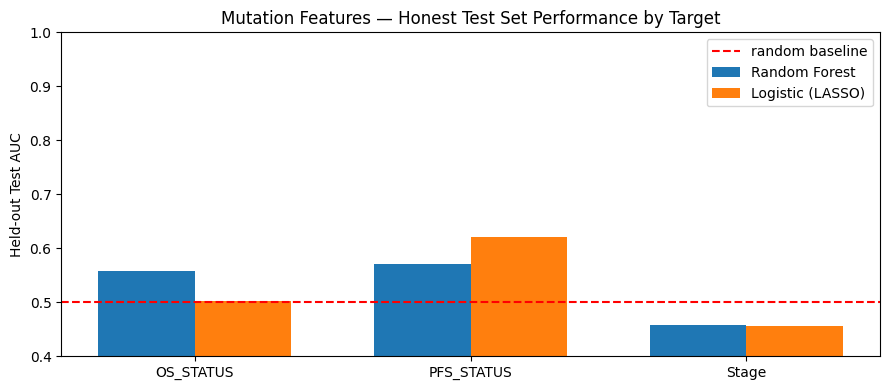

In [139]:
# Summary: test AUC per target per model
all_results = {
    'OS_STATUS':  os_results,
    'PFS_STATUS': pfs_results,
    'Stage':      stage_results,
}
model_names = list(os_results.keys())

fig, ax = plt.subplots(figsize=(9, 4))
x     = np.arange(len(all_results))
width = 0.35

for i, mname in enumerate(model_names):
    test_aucs = [all_results[t][mname]['test_auc'] for t in all_results]
    ax.bar(x + i*width, test_aucs, width, label=mname)

ax.axhline(0.5, color='red', linestyle='--', label='random baseline')
ax.set_xticks(x + width/2)
ax.set_xticklabels(list(all_results.keys()))
ax.set_ylabel('Held-out Test AUC')
ax.set_title('Mutation Features — Honest Test Set Performance by Target')
ax.legend()
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

## Step 9 — Model Selection

Pick the best model per target based on held-out test AUC (the honest score).

In [140]:
task_registry = {
    'OS_STATUS':  {'results': os_results,    'genes': os_genes,    'scoring': 'roc_auc'},
    'PFS_STATUS': {'results': pfs_results,   'genes': pfs_genes,   'scoring': 'roc_auc'},
    'Stage':      {'results': stage_results, 'genes': stage_genes, 'scoring': 'roc_auc_ovr_weighted'},
}

print(f"{'Target':<14} {'Model':<25} {'CV AUC (train)':>16} {'Test AUC':>10}  Decision")
print("-" * 85)

selected_models = {}
for target, info in task_registry.items():
    res = info['results']
    # Select by highest held-out test AUC (the honest score)
    best_name = max(res, key=lambda k: res[k]['test_auc'])
    selected_models[target] = best_name

    for name, scores in res.items():
        cv_mean = scores['cv_scores'].mean()
        cv_std  = scores['cv_scores'].std()
        t_auc   = scores['test_auc']
        marker  = " ← SELECTED" if name == best_name else ""
        print(f"{target:<14} {name:<25} {cv_mean:.3f} ± {cv_std:.3f}   {t_auc:>8.3f}{marker}")

Target         Model                       CV AUC (train)   Test AUC  Decision
-------------------------------------------------------------------------------------
OS_STATUS      Random Forest             0.729 ± 0.038      0.558 ← SELECTED
OS_STATUS      Logistic (LASSO)          0.620 ± 0.043      0.503
PFS_STATUS     Random Forest             0.645 ± 0.025      0.571
PFS_STATUS     Logistic (LASSO)          0.651 ± 0.030      0.620 ← SELECTED
Stage          Random Forest             0.630 ± 0.031      0.458 ← SELECTED
Stage          Logistic (LASSO)          0.561 ± 0.053      0.456


## Step 10 — Retrain Best Models on Full Data + Save to Feature Store

Feature store layout:
```
Data/feature_store/
  mutation/
    OS_STATUS/
      features.csv      ← patient × gene matrix (selected genes only)
      gene_list.txt     ← one gene per line
      model.joblib      ← fitted sklearn model
      metadata.json     ← AUC, gene count, model type, date
    PFS_STATUS/  ...
    Stage/       ...
  registry.json         ← index of all stored models
```

In [141]:
import joblib, json, os
from datetime import date

FEATURE_STORE_ROOT = '../../Data/feature_store/mutation'

model_blueprints = {
    'Random Forest':    lambda: RandomForestClassifier(n_estimators=500, random_state=42,
                                                       class_weight='balanced', n_jobs=-1),
    'Logistic (LASSO)': lambda: LogisticRegression(solver='saga', l1_ratio=1, C=0.5,
                                                    random_state=42, class_weight='balanced',
                                                    max_iter=5000),
}

registry = {}

for target, info in task_registry.items():
    genes      = info['genes']
    scoring    = info['scoring']
    model_name = selected_models[target]
    res        = info['results'][model_name]

    # Retrain best model on ALL data (train + test) for deployment
    final_model = model_blueprints[model_name]()
    final_model.fit(X_all[genes], ml_ready[target])

    store_dir = os.path.join(FEATURE_STORE_ROOT, target)
    os.makedirs(store_dir, exist_ok=True)

    X_all[genes].to_csv(os.path.join(store_dir, 'features.csv'))

    with open(os.path.join(store_dir, 'gene_list.txt'), 'w') as f:
        f.write('\n'.join(genes))

    joblib.dump(final_model, os.path.join(store_dir, 'model.joblib'))

    meta = {
        'target':        target,
        'model_type':    model_name,
        'n_genes':       len(genes),
        'cv_auc_mean':   round(res['cv_scores'].mean(), 4),
        'cv_auc_std':    round(res['cv_scores'].std(),  4),
        'test_auc':      round(res['test_auc'], 4),   # honest score — use this
        'scoring':       scoring,
        'train_patients': len(ml_train),
        'test_patients':  len(ml_test),
        'total_patients': len(ml_ready),
        'created':        str(date.today()),
    }
    with open(os.path.join(store_dir, 'metadata.json'), 'w') as f:
        json.dump(meta, f, indent=2)

    registry[target] = meta
    print(f"✓ {target:<14} | {model_name:<25} | CV {meta['cv_auc_mean']:.3f} | Test {meta['test_auc']:.3f} | {len(genes)} genes")

with open(os.path.join(FEATURE_STORE_ROOT, '../registry_mutation.json'), 'w') as f:
    json.dump(registry, f, indent=2)

print(f"\nFeature store saved → {FEATURE_STORE_ROOT}")

✓ OS_STATUS      | Random Forest             | CV 0.729 | Test 0.558 | 36 genes


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✓ PFS_STATUS     | Logistic (LASSO)          | CV 0.651 | Test 0.621 | 30 genes
✓ Stage          | Random Forest             | CV 0.630 | Test 0.458 | 43 genes

Feature store saved → ../../Data/feature_store/mutation


## How to reload from the Feature Store in another notebook

```python
import joblib, json, pandas as pd

target = 'OS_STATUS'   # or 'PFS_STATUS', 'Stage'
store_dir = f'../../Data/feature_store/mutation/{target}'

# Load features
features = pd.read_csv(f'{store_dir}/features.csv', index_col=0)

# Load model
model = joblib.load(f'{store_dir}/model.joblib')

# Load metadata
with open(f'{store_dir}/metadata.json') as f:
    meta = json.load(f)

print(meta)
predictions = model.predict(features)
```